In [28]:
!pip install torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [30]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

In [31]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Neutral initialization
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) * 0.01)

    def forward(self, x):
        temperature = 5.0
        gates = torch.sigmoid(self.gate_scores * temperature)
        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

    def get_gates(self):
        return torch.sigmoid(self.gate_scores * 5.0)

In [32]:
class PrunableMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


    def sparsity_loss(self):
        total = 0
        count = 0
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates = torch.sigmoid(m.gate_scores * 5.0)
                total += gates.sum()
                count += gates.numel()
        return total / count

    def sparsity_level(self, threshold=0.1):
        all_gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                all_gates.append(m.get_gates().view(-1))

        all_gates = torch.cat(all_gates)
        pruned = (all_gates < threshold).float().sum()
        total = all_gates.numel()

        return 100 * pruned / total

In [33]:
def train_model(lambda_val, epochs=20):
    model = PrunableMLP().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print(f"\nTraining with λ = {lambda_val}")

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        current_lambda = lambda_val

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            ce_loss = criterion(outputs, labels)
            sp_loss = model.sparsity_loss()

            loss = ce_loss + current_lambda * sp_loss
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_gate = model.sparsity_loss().item()
        sparsity = model.sparsity_level().item()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {running_loss:.2f} | "
              f"CE: {ce_loss.item():.4f} | "
              f"SP: {sp_loss.item():.4f} | "
              f"AvgGate: {avg_gate:.4f} | "
              f"Sparsity: {sparsity:.2f}%")

    return model

In [34]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    sparsity = model.sparsity_level().item()

    return accuracy, sparsity

In [35]:
lambdas = [1.0, 5.0, 10.0]

results = []
models = []

for lam in lambdas:
    model = train_model(lam, epochs=20)
    acc, sparsity = evaluate_model(model)

    results.append((lam, acc, sparsity))
    models.append(model)

    print(f"\nλ={lam} → Accuracy={acc:.2f}%, Sparsity={sparsity:.2f}%")


Training with λ = 1.0
Epoch [1/20] Loss: 826.15 | CE: 1.4572 | SP: 0.3359 | AvgGate: 0.3357 | Sparsity: 0.00%
Epoch [2/20] Loss: 690.27 | CE: 1.4652 | SP: 0.2782 | AvgGate: 0.2781 | Sparsity: 3.76%
Epoch [3/20] Loss: 622.82 | CE: 1.3060 | SP: 0.2460 | AvgGate: 0.2459 | Sparsity: 12.28%
Epoch [4/20] Loss: 574.32 | CE: 1.2315 | SP: 0.2248 | AvgGate: 0.2248 | Sparsity: 19.38%
Epoch [5/20] Loss: 534.07 | CE: 1.1362 | SP: 0.2097 | AvgGate: 0.2096 | Sparsity: 24.95%
Epoch [6/20] Loss: 499.13 | CE: 1.3356 | SP: 0.1982 | AvgGate: 0.1982 | Sparsity: 29.46%
Epoch [7/20] Loss: 467.63 | CE: 0.9565 | SP: 0.1892 | AvgGate: 0.1892 | Sparsity: 33.11%
Epoch [8/20] Loss: 435.03 | CE: 0.8149 | SP: 0.1820 | AvgGate: 0.1820 | Sparsity: 36.11%
Epoch [9/20] Loss: 406.42 | CE: 0.7551 | SP: 0.1761 | AvgGate: 0.1761 | Sparsity: 38.65%
Epoch [10/20] Loss: 377.72 | CE: 0.6864 | SP: 0.1711 | AvgGate: 0.1711 | Sparsity: 40.85%
Epoch [11/20] Loss: 353.78 | CE: 0.7000 | SP: 0.1668 | AvgGate: 0.1667 | Sparsity: 42.77

In [36]:
print("\nFinal Results:\n")
print("Lambda\t\tAccuracy\tSparsity (%)")
for lam, acc, sp in results:
    print(f"{lam}\t\t{acc:.2f}\t\t{sp:.2f}")


Final Results:

Lambda		Accuracy	Sparsity (%)
1.0		54.74		53.29
5.0		56.44		88.78
10.0		55.92		95.39


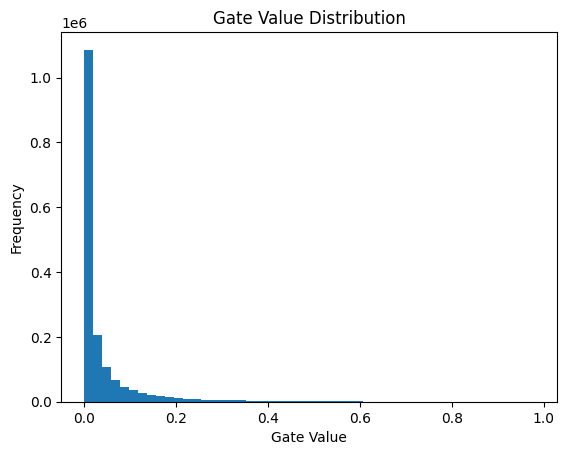

In [37]:
best_model = models[np.argmax([r[1] for r in results])]

all_gates = []
for m in best_model.modules():
    if isinstance(m, PrunableLinear):
        all_gates.append(m.get_gates().detach().cpu().view(-1))

all_gates = torch.cat(all_gates).numpy()

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()

In [38]:
threshold = 1e-2
pruned_ratio = (all_gates < threshold).sum() / len(all_gates)

print(f"Hard-pruned weights (%): {pruned_ratio * 100:.2f}%")

Hard-pruned weights (%): 50.52%
